<center><h1>Практическая работа №8</h1></center>

<center><h2>Тема работы: "Анализ текстовых данных"</h2></center>

<h5>Цель работы: применить методы кластеризации для группировки текстовых документов, оценить качество кластеризации с помощью метрик, а также исследовать влияние снижения размерности (PCA) на результаты кластеризации на примере коллекции текстовых документов.</h5>

<h5>Ход работы:</h5>

<h4>1. Загрузка библиотек и данных.</h4>

In [23]:
# Импорт библиотек для работы с текстом
import string # модуль для работы со строками и пунктуацией
import warnings # модуль для управления предупреждениями
warnings.filterwarnings('ignore')  # отключаем предупреждения для чистоты вывода

# NLTK для токенизации и стоп-слов
try:
    import nltk # библиотека для обработки естественного языка
    from nltk.tokenize import word_tokenize # функция для разбиения текста на токены (слова)
    from nltk.corpus import stopwords # корпус стоп-слов для разных языков
    
    # Загрузка необходимых ресурсов NLTK
    try:
        nltk.download('punkt_tab', quiet=True) # загружаем токенизатор (новая версия)
        nltk.download('stopwords', quiet=True) # загружаем список стоп-слов
    except: # quiet=True - скрывает сообщения о прогрессе загрузки и статусе
        nltk.download('punkt', quiet=True) # загружаем токенизатор (старая версия)
        nltk.download('stopwords', quiet=True) # загружаем список стоп-слов
        
except ImportError:
    print("Установите NLTK: pip install nltk")
    import sys
    sys.exit(1)

# pymorphy3 для лемматизации русских слов
import pymorphy3 # библиотека для морфологического анализа и лемматизации русского языка

# Библиотеки для машинного обучения
from sklearn.feature_extraction.text import TfidfVectorizer # векторизатор TF-IDF для преобразования текста в числа
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN # алгоритмы кластеризации
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score # метрики качества кластеризации
from sklearn.decomposition import PCA # метод главных компонент для снижения размерности
from sklearn.preprocessing import StandardScaler # масштабирование данных
from sklearn.neighbors import NearestNeighbors # поиск ближайших соседей для каждой точки

# Библиотеки для визуализации и работы с данными
import pandas as pd # библиотека для работы с табличными данными
import numpy as np # библиотека для численных вычислений
import matplotlib.pyplot as plt # библиотека для построения графиков
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster # функции для построения дендрограммы

from IPython.display import Markdown, display # для красивого отображения таблиц в Jupyter

In [24]:
documents = [
    # Положительные отзывы о научной фантастике
    "Этот фантастический фильм просто великолепен! Потрясающие спецэффекты и захватывающий сюжет.",
    "Очень интересный научно-фантастический роман. Заставляет задуматься о будущем человечества.",
    "Прекрасная фантастика! Неожиданные повороты сюжета и глубокая философия.",
    "Лучший фантастический фильм десятилетия. Актерская игра на высоте.",
    "Фантастика высокого уровня. Рекомендую всем любителям жанра.",
   
    # Негативные отзывы о фантастике
    "Скучная фантастика. Затянутый сюжет и плохая игра актеров.",
    "Разочарован этим фантастическим фильмом. Ожидал большего.",
    "Неинтересная фантастическая история. Потраченного времени жаль.",
   
    # Положительные отзывы о драме
    "Замечательная драма! Глубокие переживания героев тронули до слез.",
    "Прекрасный драматический фильм о жизни и любви. Очень трогательно.",
    "Отличная драма с великолепной актерской игрой. Смотрел на одном дыхании.",
   
    # Негативные отзывы о драме
    "Скучная драма. Медленное повествование и невыразительные герои.",
    "Не понравилась эта драма. Слишком затянуто и грустно.",
    "Обычная драма, ничего особенного. Проходной фильм.",
   
    # Нейтральный/смешанный отзыв
    "Неплохая фантастическая драма, но местами затянуто. На один раз."
]

<h4>2. Функция предобработки текста.</h4>

In [ ]:
def preprocess_text(text: str, morph_analyzer: pymorphy3.MorphAnalyzer, stop_words: set) -> str:
    """
    Функция предобработки текста для кластеризации.
    
    Параметры:
    -----------
    -   text — Исходный текст для обработки
    -   morph_analyzer — Анализатор для лемматизации
    -   stop_words — Множество стоп-слов для удаления
    
    Возвращает:
    -----------
    -   Обработанный текст (лемматизированные токены через пробел)
    """
    # 1. Приведение к нижнему регистру
    text = text.lower()
    
    # 2. Удаление пунктуации
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 3. Токенизация (разбиение на слова)
    try:
        tokens = word_tokenize(text, language='russian')
    except LookupError:
        # Если русский токенизатор не загружен, пробуем английский
        try:
            tokens = word_tokenize(text, language='english')
        except:
            # Если ничего не работает, используем split()
            tokens = text.split()
    
    # 4. Удаление стоп-слов и лемматизация
    processed = [] # список для хранения обработанных токенов
    for token in tokens:
        # Удаляем стоп-слова и слишком короткие токены
        if token not in stop_words and len(token) > 2:
            try:
                # Лемматизация - приведение слова к начальной форме
                lemma = morph_analyzer.parse(token)[0].normal_form
                processed.append(lemma)
            except:
                # Если лемматизация не удалась, оставляем исходный токен
                processed.append(token)
    
    # Возвращаем обработанный текст как строку
    return ' '.join(processed)


# Загрузка русских стоп-слов
try:
    russian_stopwords = set(stopwords.words('russian'))
except LookupError:
    # Резервный набор стоп-слов если NLTK не загрузился
    russian_stopwords = {'это', 'а', 'так', 'и', 'в', 'на', 'с', 'по', 'но', 'не', 'очень'}

# Добавляем дополнительные стоп-слова для нашего датасета
custom_stopwords = russian_stopwords.union({'этот', 'эта', 'такой', 'всех', 'раз'})

# Инициализация морфологического анализатора
morph = pymorphy3.MorphAnalyzer()

print(f"Количество стоп-слов: {len(custom_stopwords)}")
print(f"Пример стоп-слов: {list(custom_stopwords)[:10]}")

Количество стоп-слов: 152
Пример стоп-слов: ['у', 'какая', 'им', 'на', 'том', 'может', 'теперь', 'они', 'перед', 'иногда']


<h4>3. Применение предобработки ко всем документам.</h4>

In [26]:
# Применяем функцию предобработки к каждому документу
processed_documents = []
for doc in documents:
    processed = preprocess_text(doc, morph, custom_stopwords)
    processed_documents.append(processed)

# Вывод результатов предобработки
print("Результаты предобработки текста")
print('-'*35)
for i, (orig, proc) in enumerate(zip(documents, processed_documents), 1):
    print(f"\n{i}. Исходный: {orig}")
    print(f"   Обработанный: {proc}")

Результаты предобработки текста
-----------------------------------

1. Исходный: Этот фантастический фильм просто великолепен! Потрясающие спецэффекты и захватывающий сюжет.
   Обработанный: фантастический фильм просто великолепный потрясать спецэффект захватывать сюжет

2. Исходный: Очень интересный научно-фантастический роман. Заставляет задуматься о будущем человечества.
   Обработанный: очень интересный научнофантастический роман заставлять задуматься будущее человечество

3. Исходный: Прекрасная фантастика! Неожиданные повороты сюжета и глубокая философия.
   Обработанный: прекрасный фантастика неожиданный поворот сюжет глубокий философия

4. Исходный: Лучший фантастический фильм десятилетия. Актерская игра на высоте.
   Обработанный: хороший фантастический фильм десятилетие актёрский игра высота

5. Исходный: Фантастика высокого уровня. Рекомендую всем любителям жанра.
   Обработанный: фантастика высокий уровень рекомендовать весь любитель жанр

6. Исходный: Скучная фантастика. 

<h4>4. TF-IDF векторизация.</h4>

<h5>
TF-IDF (Term Frequency-Inverse Document Frequency) — метод векторизации текста, который оценивает важность слова в документе относительно всей коллекции документов (корпуса).<br>
Принцип работы:
<ul>
    <li>TF — частота термина в документе. То есть "Насколько часто слово встречается в ЭТОМ документе?" (чем чаще слово в документе, тем выше его вес).</li>
    <li>IDF — обратная частота документа. То есть "Насколько редко слово встречается во ВСЕХ документах?" (чем реже слово в корпусе, тем выше его вес).</li>
    <li>TF-IDF = TF × IDF.</li>
</ul>
Если суммировать, то TF-IDF отвечает на вопрос: "Насколько это слово важно именно для этого документа, а не для всех сразу?".
</h5>

In [27]:
# Создание TF-IDF векторизатора
tfidf_vectorizer = TfidfVectorizer(
    max_features=100, # оставить только 100 самых важных слов
    min_df=1, # игнорировать слова, которые есть в <1 документе (минимальная частота документа)
    max_df=0.95 # игнорировать слова, которые есть в >95% документов (максимальная частота документа)
)

# Обучение и преобразование обработанных документов в TF-IDF матрицу
X_tfidf = tfidf_vectorizer.fit_transform(processed_documents)

# Получение имен признаков
feature_names = tfidf_vectorizer.get_feature_names_out()

# Создаем DataFrame
df = pd.DataFrame(
    X_tfidf.toarray().round(3),  # Округляем до 3 знаков для читаемости
    columns=feature_names
)
df['Исходный_текст'] = documents

print("TF-IDF векторизация")
print('-'*20)
print(f"Размерность TF-IDF матрицы: {X_tfidf.shape}") # (количество документов, количество признаков)

print("\nМатрица признаков (TF-IDF):")
print('-'*30)
print(df.to_string())

# Создаем копию DataFrame
df_features = df.drop(columns=['Исходный_текст'])

# Создаем новый список для столбца "Векторизация (используемые слова)"
used_words_list = []

for index, row in df_features.iterrows():
    words = row[row > 0].index.tolist()
    # row[row > 0] выбирает только столбцы со значением > 0
    # .index возвращает названия этих столбцов
    
    # Объединяем слова в одну строку через пробел
    used_words_str = " ".join(words)
    used_words_list.append(used_words_str)

# Добавляем новый столбец в исходный DataFrame
df['Векторизация (используемые слова)'] = used_words_list

# Выбираем только нужные столбцы для финального вывода
final_df = df[['Исходный_текст', 'Векторизация (используемые слова)']]

# Вывод результата
print("\nРезультат векторизации:")
print("-" * 25)
print(final_df.to_string())

TF-IDF векторизация
--------------------
Размерность TF-IDF матрицы: (15, 71)

Матрица признаков (TF-IDF):
------------------------------
    актёр  актёрский  больший  будущее  великолепный   весь  время  высокий  высота  герой  глубокий  грустно  десятилетие  драма  драматический  дыхание  жаль   жанр  жизнь  задуматься  замечательный  заставлять  затянутый  захватывать   игра  интересный  история  любитель  любовь  медленный  место  научнофантастический  невыразительный  неинтересный  неожиданный  неплохой  обычный   один  ожидать  особенный  отличный  очень  переживание  плохой  повествование  поворот  понравиться  потратить  потрясать  прекрасный  просто  проходная  разочаровать  рекомендовать  роман  скучный  слеза  слишком  смотреть  спецэффект  сюжет  трогательно  тронуть  уровень  фантастика  фантастический  философия  фильм  хороший  человечество    это                                                                                Исходный_текст
0    0.00      0.000    0.000 

<h4>5. Определение оптимального количества кластеров (метод локтя).</h4>

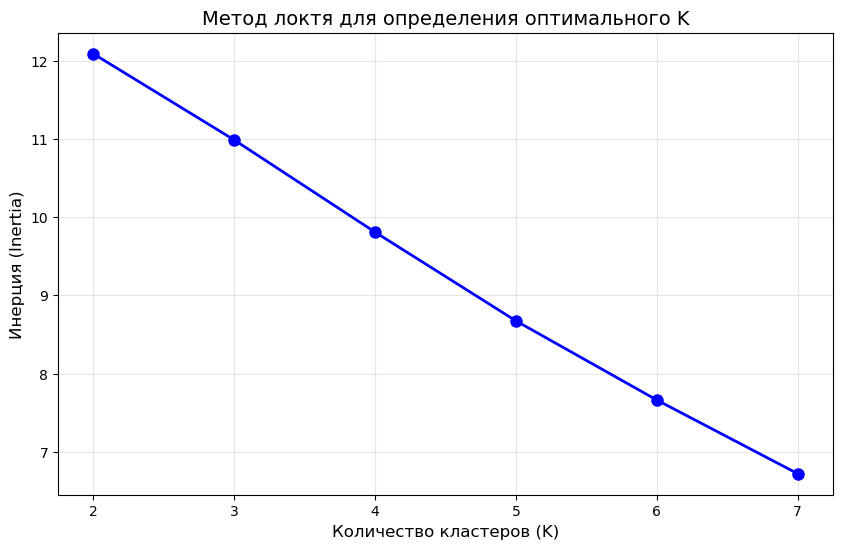

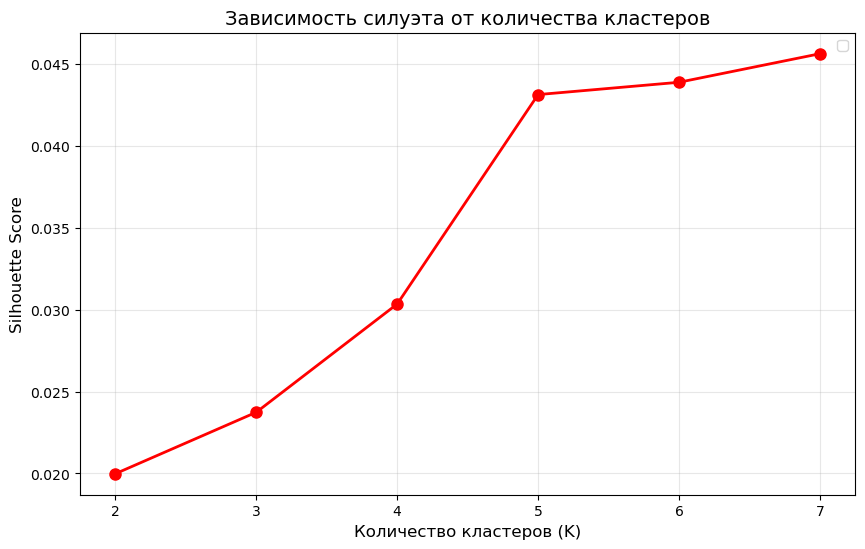


Оптимальное количество кластеров (по методу локтя): K = 3


In [28]:
# Метод локтя для определения оптимального K
inertias = []
silhouettes = []
K_range = range(2, 8)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_tfidf.toarray())
    inertias.append(kmeans_temp.inertia_)
    sil = silhouette_score(X_tfidf.toarray(), labels)
    silhouettes.append(sil)

# Визуализация метода локтя
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Количество кластеров (K)', fontsize=12)
plt.ylabel('Инерция (Inertia)', fontsize=12)
plt.title('Метод локтя для определения оптимального K', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Количество кластеров (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Зависимость силуэта от количества кластеров', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# На основе графика выбираем K=3 (изгиб кривой)
optimal_k = 3
print(f"\nОптимальное количество кластеров (по методу локтя): K = {optimal_k}")

<h4>6. Кластеризация на исходных TF-IDF данных.</h4>

<h4>6.1. K-Means кластеризация.</h4>

<h5>
K-Means (K-средних) — это один из самых простых и популярных алгоритмов кластеризации, который разделяет данные на заданное количество групп (кластеров) K.<br>
Как работает:
<ol>
    <li>Инициализация: Алгоритм случайным образом выбирает K точек в качестве центров кластеров</li>
    <li>Назначение: Каждая точка данных приписывается к ближайшему центру</li>
    <li>Обновление: Центры кластеров пересчитываются как среднее всех точек в кластере</li>
    <li>Повторение: Шаги 2-3 повторяются, пока центры кластеров не перестанут меняться или изменения не станут минимальными</li>
</ol>
</h5>

In [29]:
# Инициализация и обучение K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
# n_init=10 - количество запусков с разными начальными центрами
labels_kmeans = kmeans.fit_predict(X_tfidf.toarray())

# Расчет метрик качества
sil_kmeans = silhouette_score(X_tfidf.toarray(), labels_kmeans)
db_kmeans = davies_bouldin_score(X_tfidf.toarray(), labels_kmeans)
ch_kmeans = calinski_harabasz_score(X_tfidf.toarray(), labels_kmeans)

print("K-MEANS кластеризация (без PCA)")
print("-" * 35)
print(f"Silhouette Score: {sil_kmeans:.4f}")
print(f"Davies-Bouldin Score: {db_kmeans:.4f}")
print(f"Calinski-Harabasz Score: {ch_kmeans:.2f}")

print(f"\nРаспределение документов по кластерам:")
for i in range(optimal_k):
    count = np.sum(labels_kmeans == i)
    print(f"  Кластер {i+1}: {count} документов")

K-MEANS кластеризация (без PCA)
-----------------------------------
Silhouette Score: 0.0237
Davies-Bouldin Score: 2.5423
Calinski-Harabasz Score: 1.27

Распределение документов по кластерам:
  Кластер 1: 6 документов
  Кластер 2: 2 документов
  Кластер 3: 7 документов


<h4>6.2. Agglomerative Clustering (Иерархическая кластеризация).</h4>

<h5>
Agglomerative Clustering (Иерархическая кластеризация) — это алгоритм кластеризации, который строит иерархию кластеров, объединяя объекты в группы на основе их близости.<br>
Как работает:
<ol>
    <li>Инициализация: Каждая точка данных изначально рассматривается как отдельный кластер</li>
    <li>Поиск ближайших кластеров: Алгоритм вычисляет расстояния между всеми парами кластеров и находит два самых близких</li>
    <li>Объединение: Два ближайших кластера объединяются в один новый кластер</li>
    <li>Обновление матрицы расстояний: Расстояния между новым кластером и остальными кластерами пересчитываются (с использованием выбранного метода linkage: ward, complete, average или single)</li>
    <li>Повторение: Шаги 2-4 повторяются, пока все точки не объединятся в один кластер или не будет достигнуто заданное количество кластеров</li>
</ol>
</h5>

In [30]:
# Инициализация и обучение иерархической кластеризации
agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
# ward - минимизирует дисперсию внутри кластеров
labels_agglo = agglo.fit_predict(X_tfidf.toarray())

# Расчет метрик качества
sil_agglo = silhouette_score(X_tfidf.toarray(), labels_agglo)
db_agglo = davies_bouldin_score(X_tfidf.toarray(), labels_agglo)
ch_agglo = calinski_harabasz_score(X_tfidf.toarray(), labels_agglo)

print("Agglomerative Clustering (без PCA)")
print("-" * 35)
print(f"Silhouette Score: {sil_agglo:.4f}")
print(f"Davies-Bouldin Score: {db_agglo:.4f}")
print(f"Calinski-Harabasz Score: {ch_agglo:.2f}")

print(f"\nРаспределение документов по кластерам:")
for i in range(optimal_k):
    count = np.sum(labels_agglo == i)
    print(f"  Кластер {i+1}: {count} документов")

Agglomerative Clustering (без PCA)
-----------------------------------
Silhouette Score: 0.0274
Davies-Bouldin Score: 2.4065
Calinski-Harabasz Score: 1.35

Распределение документов по кластерам:
  Кластер 1: 8 документов
  Кластер 2: 4 документов
  Кластер 3: 3 документов


<h4>6.3. DBSCAN кластеризация.</h4>

<h5>
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) — это алгоритм кластеризации, основанный на плотности распределения точек. Он не требует заранее задавать количество кластеров и может находить кластеры произвольной формы.<br>
Как работает:
<ol>
    <li>Определение соседей: Для каждой точки алгоритм проверяет, сколько других точек находится в её окрестности радиуса eps</li>
    <li>Поиск ядерных точек: Если в окрестности точки находится не менее min_samples точек, она становится ядром кластера</li>
    <li>Расширение кластеров: Все точки, достижимые из ядра (находящиеся на расстоянии eps друг от друга), включаются в тот же кластер</li>
    <li>Определение шума: Точки, которые не попадают ни в один кластер, помечаются как шум (метка -1)</li>
</ol>
</h5>

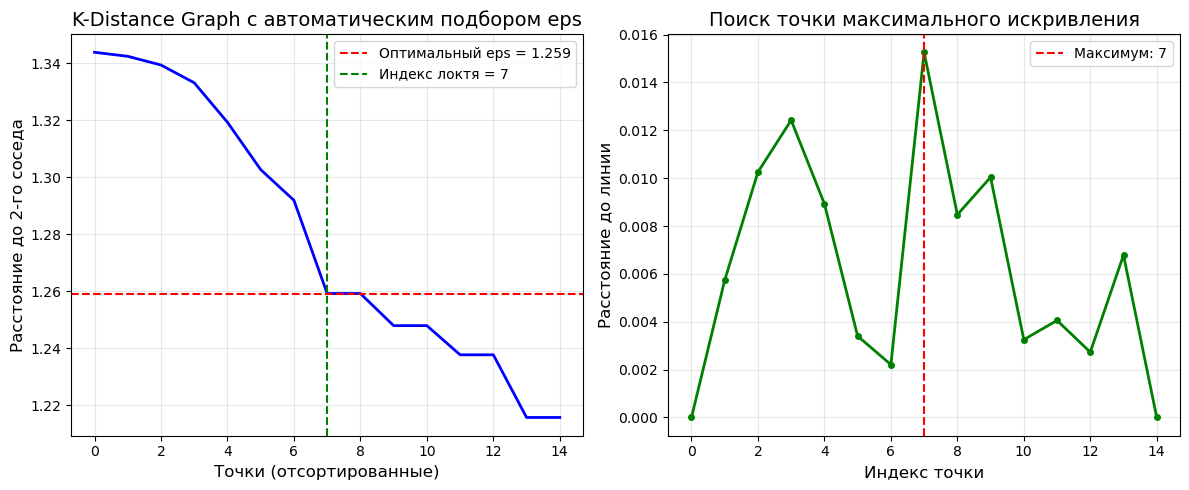

Автоматически подобранное eps: 1.2592
Индекс 'локтя': 7 из 15 точек


In [31]:
def find_optimal_eps(X: list, min_samples: int, plot: bool=True) -> float:
    """
    Автоматический подбор eps для DBSCAN методом K-Distance.
    
    Параметры:
    -----------
    -   X — Данные для кластеризации (массив признаков)
    -   min_samples — Минимальное количество точек в кластере
    -   plot — Показывать график для наглядности
    
    Возвращает:
    -----------
    -   Оптимальное значение eps
    """
    k = min_samples
    
    # Создаём и обучаем модель поиска соседей
    neighbors = NearestNeighbors(n_neighbors=k) # для каждой точки ищем k ближайших соседей
    neighbors_fit = neighbors.fit(X)

    # Находим k ближайших соседей для каждой точки
    distances, indices = neighbors_fit.kneighbors(X)
    # distances - расстояния до k соседей
    # indices - индексы k соседей
    
    # Сортируем расстояния по убыванию
    distances = np.sort(distances[:, k-1])[::-1] # [:, k-1] - все строки, k-й сосед
    
    # Автоматическое обнаружение "локтя" (точка максимального искривления)
    x = np.arange(len(distances)) # [0, 1, 2, 3, ...] - индексы точек
    y = distances # значения расстояний
    
    # Нормализуем оси для корректного вычисления расстояния, чтобы разные масштабы X и Y не влияли на результат
    x_norm = x / np.max(x) # нормализуем к [0, 1]
    y_norm = y / np.max(y)
    
    # Создаём линию между первой и последней точкой графика
    line_start = np.array([0, y_norm[0]]) # координаты первой точки базовой линии
    line_end = np.array([1, y_norm[-1]]) # координаты последней точки базовой линии
    
    # Находим точку, максимально удаленную от этой линии, это и будет "локоть"
    distances_to_line = []
    for i in range(len(x_norm)):
        point = np.array([x_norm[i], y_norm[i]]) # координаты конкретной (i) точки
        # Расстояние от точки до прямой
        distance = np.abs(np.cross(line_end - line_start, line_start - point)) / \
                   np.linalg.norm(line_end - line_start)
        # перпендикуляр (высота) = площадь параллелограмма (=векторное произведение) / основание (длина линии)
        distances_to_line.append(distance)
    
    elbow_idx = np.argmax(distances_to_line) # находит индекс элемента с самым большим значением
    optimal_eps = distances[elbow_idx]
    
    # Визуализация
    if plot:
        plt.figure(figsize=(12, 5))
        
        # График 1: K-Distance Graph
        plt.subplot(1, 2, 1)
        plt.plot(distances, 'b-', linewidth=2)
        plt.axhline(y=optimal_eps, color='r', linestyle='--', 
                   label=f'Оптимальный eps = {optimal_eps:.3f}') # горизонтальная линия
        plt.axvline(x=elbow_idx, color='g', linestyle='--', 
                   label=f'Индекс локтя = {elbow_idx}') # вертикальная линия
        plt.xlabel('Точки (отсортированные)', fontsize=12)
        plt.ylabel(f'Расстояние до {k}-го соседа', fontsize=12)
        plt.title('K-Distance Graph с автоматическим подбором eps', fontsize=14)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # График 2: Расстояния до линии (поиск максимума)
        plt.subplot(1, 2, 2)
        plt.plot(distances_to_line, 'go-', linewidth=2, markersize=4)
        plt.axvline(x=elbow_idx, color='r', linestyle='--', 
                   label=f'Максимум: {elbow_idx}')
        plt.xlabel('Индекс точки', fontsize=12)
        plt.ylabel('Расстояние до линии', fontsize=12)
        plt.title('Поиск точки максимального искривления', fontsize=14)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout() # автоматически подбирает отступы между графиками
        plt.show()
    
    print(f"Автоматически подобранное eps: {optimal_eps:.4f}")
    print(f"Индекс 'локтя': {elbow_idx} из {len(distances)} точек")
    
    return optimal_eps

# Автоматически находим оптимальный eps
optimal_eps = find_optimal_eps(X_tfidf.toarray(), min_samples=2, plot=True)

In [32]:
dbscan = DBSCAN(eps=optimal_eps, min_samples=2)
# eps - радиус окрестности (подбирается экспериментально)
# min_samples=2 - минимальное количество точек в кластере
labels_dbscan = dbscan.fit_predict(X_tfidf.toarray())

# Количество кластеров (исключая шум)
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
# set(labels_dbscan) - уникальные метки кластеров
n_noise_dbscan = list(labels_dbscan).count(-1) # считаем шумовые точки

print("DBSCAN кластеризация (без PCA)")
print("-" * 35)
print(f"Количество кластеров: {n_clusters_dbscan}")
print(f"Количество шумовых точек: {n_noise_dbscan}")

# Расчет метрик (только для не-шумовых точек)
if n_clusters_dbscan > 1:
    mask = labels_dbscan != -1 # маска для не-шумовых точек
    sil_dbscan = silhouette_score(X_tfidf.toarray()[mask], labels_dbscan[mask])
    db_dbscan = davies_bouldin_score(X_tfidf.toarray()[mask], labels_dbscan[mask])
    ch_dbscan = calinski_harabasz_score(X_tfidf.toarray()[mask], labels_dbscan[mask])
    
    print(f"\nSilhouette Score: {sil_dbscan:.4f}")
    print(f"Davies-Bouldin Score: {db_dbscan:.4f}")
    print(f"Calinski-Harabasz Score: {ch_dbscan:.2f}")

    print(f"\nРаспределение документов по кластерам:")
    for i in range(n_clusters_dbscan):
        count = np.sum(labels_dbscan == i)
        print(f"  Кластер {i+1}: {count} документа")
else:
    sil_dbscan, db_dbscan, ch_dbscan = 0, 0, 0
    print("\nНедостаточно кластеров для расчета метрик")

DBSCAN кластеризация (без PCA)
-----------------------------------
Количество кластеров: 4
Количество шумовых точек: 7

Silhouette Score: 0.0843
Davies-Bouldin Score: 1.1972
Calinski-Harabasz Score: 1.44

Распределение документов по кластерам:
  Кластер 1: 2 документа
  Кластер 2: 2 документа
  Кластер 3: 2 документа
  Кластер 4: 2 документа


<h4>7. Интерпретация кластеров (без PCA).</h4>

In [33]:
def interpret_clusters(documents: list, labels: list, model_name: str):
    """
    Функция для интерпретации кластеров любой модели.
    
    Параметры:
    -----------
    -   documents — Список исходных документов
    -   labels — Метки кластеров для каждого документа
    -   model_name — Название модели для заголовка
    
    Возвращает:
    -----------
    -   Документы указанного кластера
    """
    print("-" * 50)
    print(f"Интерпретация кластеров {model_name}")
    print("-" * 50)
    
    # Получаем уникальные метки кластеров (исключая шум -1 для DBSCAN)
    unique_labels = set(labels)
    if -1 in unique_labels:
        unique_labels.remove(-1)
    
    for i in sorted(unique_labels):
        cluster_docs = [documents[j] for j in range(len(documents)) if labels[j] == i]
        print(f"\n📁 Кластер {i+1} ({len(cluster_docs)} документов):")
        print("-" * 30)
        for j, doc in enumerate(cluster_docs, 1):
            # Определяем тональность и тему
            if 'фантаст' in doc.lower():
                topic = "🚀 Фантастика"
            elif 'драм' in doc.lower():
                topic = "🎭 Драма"
            else:
                topic = "📝 Смешанный"
            
            if any(word in doc.lower() for word in ['великолеп', 'прекрас', 'отлич', 'замечатель', 'лучш', 'интерес', 'рекоменд']):
                sentiment = "✅ Положительный"
            elif any(word in doc.lower() for word in ['скучн', 'разочарован', 'неинтерес', 'не понрав', 'плох']):
                sentiment = "❌ Негативный"
            else:
                sentiment = "⚪ Нейтральный"
            
            print(f"  {j}. {topic} | {sentiment}")
            print(f"     {doc[:80]}...")
    
    # Для DBSCAN показываем шумовые точки
    if -1 in set(labels):
        noise_docs = [documents[j] for j in range(len(documents)) if labels[j] == -1]
        print(f"\n🔇 Шумовые точки ({len(noise_docs)} документов):")
        print("-" * 35)
        for j, doc in enumerate(noise_docs, 1):
            print(f"  {j}. {doc[:80]}...")
    print()

interpret_clusters(documents, labels_kmeans, "K-Means без PCA")
interpret_clusters(documents, labels_agglo, "Agglomerative без PCA")
interpret_clusters(documents, labels_dbscan, "DBSCAN без PCA")

--------------------------------------------------
Интерпретация кластеров K-Means без PCA
--------------------------------------------------

📁 Кластер 1 (6 документов):
------------------------------
  1. 🚀 Фантастика | ✅ Положительный
     Очень интересный научно-фантастический роман. Заставляет задуматься о будущем че...
  2. 🚀 Фантастика | ✅ Положительный
     Прекрасная фантастика! Неожиданные повороты сюжета и глубокая философия....
  3. 🚀 Фантастика | ✅ Положительный
     Фантастика высокого уровня. Рекомендую всем любителям жанра....
  4. 🚀 Фантастика | ❌ Негативный
     Скучная фантастика. Затянутый сюжет и плохая игра актеров....
  5. 🎭 Драма | ❌ Негативный
     Не понравилась эта драма. Слишком затянуто и грустно....
  6. 🚀 Фантастика | ❌ Негативный
     Неплохая фантастическая драма, но местами затянуто. На один раз....

📁 Кластер 2 (2 документов):
------------------------------
  1. 🎭 Драма | ✅ Положительный
     Замечательная драма! Глубокие переживания героев тронули до

<h4>8. Применение PCA к TF-IDF матрице.</h4>

<h5>
PCA (Principal Component Analysis — Метод главных компонент) — это алгоритм уменьшения размерности данных, который позволяет "сжать" информацию из множества признаков в меньшее количество новых признаков (главных компонент) с минимальными потерями информации.<br>
Как работает:
<ol>
    <li>Центрирование данных: Данные смещаются так, чтобы среднее значение стало 0</li>
    <li>Ищем главное направление: PCA ищет линию, вдоль которой точки разбросаны сильнее всего (максимальная дисперсия)</li>
    <li>Ищем второе направление: Второе направление — перпендикулярно первому</li>
    <li>Отбрасываем неважные направления: Если у нас 8 признаков, то PCA найдет 8 направлений (компонент). Но последние из них будут описывать мелкие детали и шум, которыми можно пренебречь. Поэтому оставляем только первые 2-4 самых важных направления (если они описывают достаточный процент дисперсии).</li>
</ol>
</h5>

In [34]:
# Масштабирование данных перед PCA
# PCA чувствителен к масштабу признаков, поэтому нужно стандартизировать
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tfidf.toarray()) # приводим данные к среднему=0, отклонению=1

# Анализ объясненной дисперсии
pca_variance = PCA(random_state=42) # создаем PCA объект
pca_variance.fit(X_scaled) # обучаем на данных

# Накопленная объясненная дисперсия
cumulative_variance = np.cumsum(pca_variance.explained_variance_ratio_) # explained_variance_ratio_ - доля дисперсии каждой компоненты
# np.cumsum() - накопленная сумма долей дисперсии

# Находим количество (поэтому +1) компонент для 85% дисперсии
n_components_85 = np.argmax(cumulative_variance >= 0.85) + 1

print("Анализ PCA")
print("-" * 15)
print(f"Для объяснения 85% дисперсии потребовалось {n_components_85} компонент")

print(f"\nОбъясненная дисперсия по компонентам:")
for i, var in enumerate(pca_variance.explained_variance_ratio_[:len(pca_variance.explained_variance_ratio_)], 1):
    print(f"  PC{i}: {var:.2%}")

print(f"\nНакопленная объясненная дисперсия:")
for i in range(n_components_85):
    print(f"  Первые {i+1} компонент: {cumulative_variance[i]:.2%}")

# Применение PCA с выбранным количеством компонент
pca = PCA(n_components=n_components_85, random_state=42)
X_pca = pca.fit_transform(X_scaled) # преобразуем данные
# fit_transform(X) — обучает и преобразует (возвращает преобразованные данные в виде матрицы)

print(f"\nФорма данных после PCA: {X_pca.shape}")

Анализ PCA
---------------
Для объяснения 85% дисперсии потребовалось 11 компонент

Объясненная дисперсия по компонентам:
  PC1: 11.35%
  PC2: 9.83%
  PC3: 8.96%
  PC4: 8.55%
  PC5: 8.26%
  PC6: 7.49%
  PC7: 7.21%
  PC8: 6.84%
  PC9: 6.46%
  PC10: 5.92%
  PC11: 5.61%
  PC12: 5.13%
  PC13: 4.50%
  PC14: 3.88%
  PC15: 0.00%

Накопленная объясненная дисперсия:
  Первые 1 компонент: 11.35%
  Первые 2 компонент: 21.18%
  Первые 3 компонент: 30.14%
  Первые 4 компонент: 38.70%
  Первые 5 компонент: 46.96%
  Первые 6 компонент: 54.45%
  Первые 7 компонент: 61.66%
  Первые 8 компонент: 68.49%
  Первые 9 компонент: 74.95%
  Первые 10 компонент: 80.88%
  Первые 11 компонент: 86.49%

Форма данных после PCA: (15, 11)


<h4>9. Визуализация данных в пространстве первых двух главных компонент.</h4>

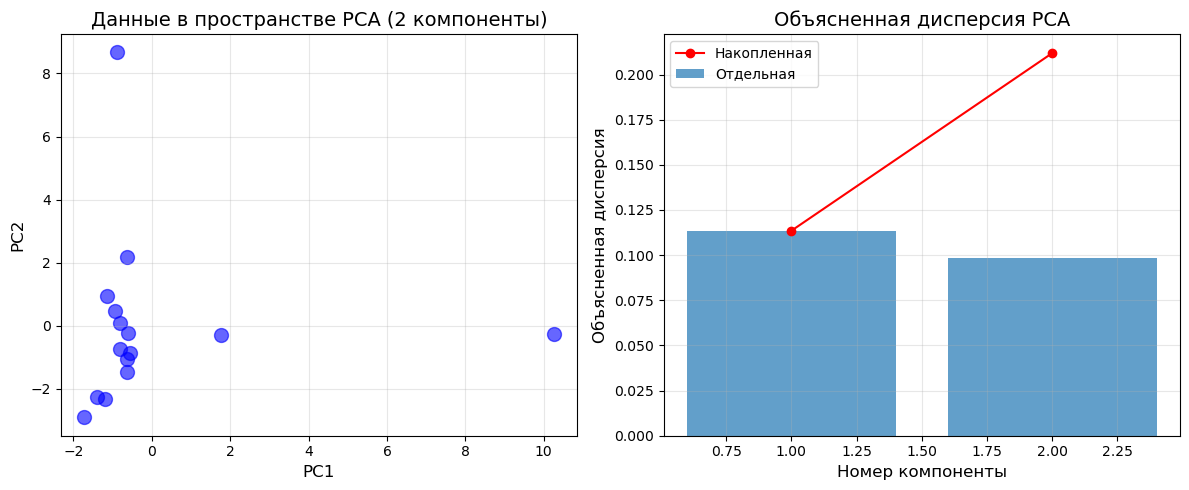

PC1 объясняет: 11.35%
PC2 объясняет: 9.83%
Вместе: 21.18%


In [35]:
# PCA с 2 компонентами для визуализации
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Визуализация
plt.figure(figsize=(12, 5))

# Исходные данные в пространстве PCA
plt.subplot(1, 2, 1)
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c='blue', alpha=0.6, s=100)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('Данные в пространстве PCA (2 компоненты)', fontsize=14)
plt.grid(True, alpha=0.3)

# Объясненная дисперсия по компонентам
plt.subplot(1, 2, 2)
plt.bar(range(1, len(pca_2d.explained_variance_ratio_) + 1), 
        pca_2d.explained_variance_ratio_, alpha=0.7, label='Отдельная')
plt.plot(range(1, len(np.cumsum(pca_2d.explained_variance_ratio_)) + 1), 
         np.cumsum(pca_2d.explained_variance_ratio_), 'ro-', label='Накопленная')
plt.xlabel('Номер компоненты', fontsize=12)
plt.ylabel('Объясненная дисперсия', fontsize=12)
plt.title('Объясненная дисперсия PCA', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PC1 объясняет: {pca_2d.explained_variance_ratio_[0]:.2%}")
print(f"PC2 объясняет: {pca_2d.explained_variance_ratio_[1]:.2%}")
print(f"Вместе: {sum(pca_2d.explained_variance_ratio_[:2]):.2%}")

<h5>
Что потенциально может показывать график слева:
<ul>
    <li>Близкие точки — документы с похожим набором слов/тем</li>
    <li>Далекие точки — документы с разными словами/темами</li>
    <li>Скопления точек — потенциальные кластеры</li>
</ul>
</h5>

<h4>10. Кластеризация на данных после PCA.</h4>

<h5>10.1. K-Means на PCA-данных.</h5>

In [36]:
kmeans_pca = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_kmeans_pca = kmeans_pca.fit_predict(X_pca)

# Расчет метрик качества
sil_kmeans_pca = silhouette_score(X_pca, labels_kmeans_pca)
db_kmeans_pca = davies_bouldin_score(X_pca, labels_kmeans_pca)
ch_kmeans_pca = calinski_harabasz_score(X_pca, labels_kmeans_pca)

print("K-MEANS кластеризация (с PCA)")
print("-" * 30)
print(f"Silhouette Score: {sil_kmeans_pca:.6f}")
print(f"Davies-Bouldin Score: {db_kmeans_pca:.6f}")
print(f"Calinski-Harabasz Score: {ch_kmeans_pca:.4f}")

print(f"\nРаспределение документов по кластерам:")
for i in range(optimal_k):
    count = np.sum(labels_kmeans_pca == i)
    print(f"  Кластер {i+1}: {count} документов")

K-MEANS кластеризация (с PCA)
------------------------------
Silhouette Score: 0.146558
Davies-Bouldin Score: 0.664787
Calinski-Harabasz Score: 1.8771

Распределение документов по кластерам:
  Кластер 1: 1 документов
  Кластер 2: 13 документов
  Кластер 3: 1 документов


<h5>10.2. Agglomerative Clustering на PCA-данных.</h5>

In [37]:
agglo_pca = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
labels_agglo_pca = agglo_pca.fit_predict(X_pca)

# Расчет метрик качества
sil_agglo_pca = silhouette_score(X_pca, labels_agglo_pca)
db_agglo_pca = davies_bouldin_score(X_pca, labels_agglo_pca)
ch_agglo_pca = calinski_harabasz_score(X_pca, labels_agglo_pca)

print("Agglomerative Clustering (с PCA)")
print("-" * 35)
print(f"Silhouette Score: {sil_agglo_pca:.6f}")
print(f"Davies-Bouldin Score: {db_agglo_pca:.6f}")
print(f"Calinski-Harabasz Score: {ch_agglo_pca:.4f}")

print(f"\nРаспределение документов по кластерам:")
for i in range(optimal_k):
    count = np.sum(labels_agglo_pca == i)
    print(f"  Кластер {i+1}: {count} документов")

Agglomerative Clustering (с PCA)
-----------------------------------
Silhouette Score: 0.146558
Davies-Bouldin Score: 0.664787
Calinski-Harabasz Score: 1.8771

Распределение документов по кластерам:
  Кластер 1: 13 документов
  Кластер 2: 1 документов
  Кластер 3: 1 документов


<h5>10.3. DBSCAN на PCA-данных.</h5>

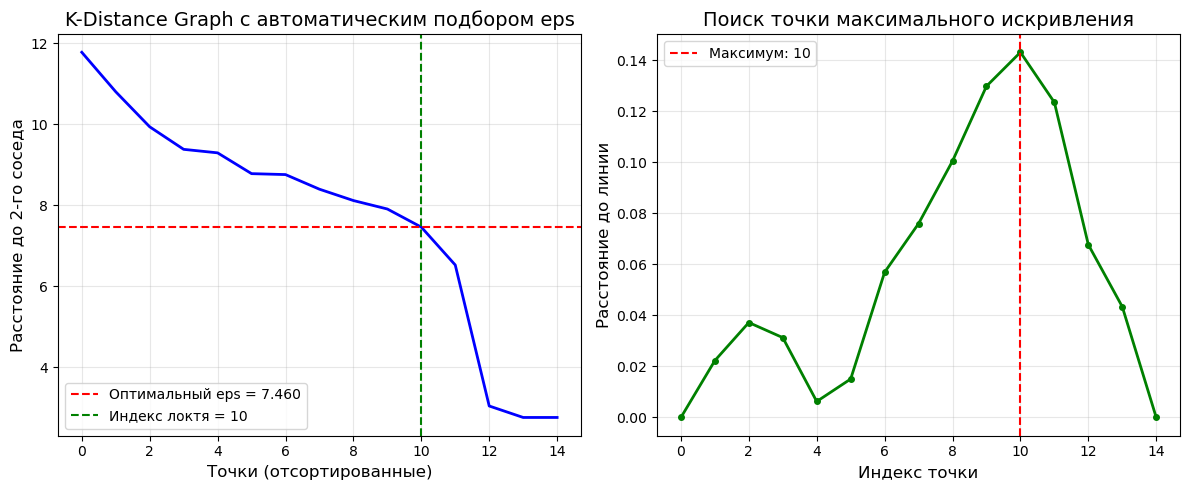

Автоматически подобранное eps: 7.4600
Индекс 'локтя': 10 из 15 точек


In [38]:
# Автоматически находим оптимальный eps для PCA данных
optimal_eps_pca = find_optimal_eps(X_pca, min_samples=2, plot=True)

In [39]:
dbscan_pca = DBSCAN(eps=optimal_eps_pca, min_samples=2)
labels_dbscan_pca = dbscan_pca.fit_predict(X_pca)

# Количество кластеров и шума
n_clusters_dbscan_pca = len(set(labels_dbscan_pca)) - (1 if -1 in labels_dbscan_pca else 0)
n_noise_dbscan_pca = list(labels_dbscan_pca).count(-1)

print("DBSCAN кластеризация (с PCA)")
print("-" * 30)
print(f"Количество кластеров: {n_clusters_dbscan_pca}")
print(f"Количество шумовых точек: {n_noise_dbscan_pca}")

# Расчет метрик (только для не-шумовых точек)
if n_clusters_dbscan_pca > 1:
    mask_pca = labels_dbscan_pca != -1
    sil_dbscan_pca = silhouette_score(X_pca[mask_pca], labels_dbscan_pca[mask_pca])
    db_dbscan_pca = davies_bouldin_score(X_pca[mask_pca], labels_dbscan_pca[mask_pca])
    ch_dbscan_pca = calinski_harabasz_score(X_pca[mask_pca], labels_dbscan_pca[mask_pca])
    
    print(f"\nSilhouette Score: {sil_dbscan_pca:.4f}")
    print(f"Davies-Bouldin Score: {db_dbscan_pca:.4f}")
    print(f"Calinski-Harabasz Score: {ch_dbscan_pca:.2f}")

    print(f"\nРаспределение документов по кластерам:")
    for i in range(n_clusters_dbscan):
        count = np.sum(labels_dbscan_pca == i)
        print(f"  Кластер {i+1}: {count} документов")
else:
    sil_dbscan_pca, db_dbscan_pca, ch_dbscan_pca = 0, 0, 0
    print("\nНедостаточно кластеров для расчета метрик")

DBSCAN кластеризация (с PCA)
------------------------------
Количество кластеров: 1
Количество шумовых точек: 10

Недостаточно кластеров для расчета метрик


<h4>11. Интерпретация кластеров (с PCA).</h4>

In [40]:
interpret_clusters(documents, labels_kmeans_pca, "K-Means с PCA")
interpret_clusters(documents, labels_agglo_pca, "Agglomerative с PCA")
interpret_clusters(documents, labels_dbscan_pca, "DBSCAN с PCA")

--------------------------------------------------
Интерпретация кластеров K-Means с PCA
--------------------------------------------------

📁 Кластер 1 (1 документов):
------------------------------
  1. 🚀 Фантастика | ✅ Положительный
     Очень интересный научно-фантастический роман. Заставляет задуматься о будущем че...

📁 Кластер 2 (13 документов):
------------------------------
  1. 🚀 Фантастика | ✅ Положительный
     Этот фантастический фильм просто великолепен! Потрясающие спецэффекты и захватыв...
  2. 🚀 Фантастика | ✅ Положительный
     Прекрасная фантастика! Неожиданные повороты сюжета и глубокая философия....
  3. 🚀 Фантастика | ✅ Положительный
     Лучший фантастический фильм десятилетия. Актерская игра на высоте....
  4. 🚀 Фантастика | ❌ Негативный
     Скучная фантастика. Затянутый сюжет и плохая игра актеров....
  5. 🚀 Фантастика | ❌ Негативный
     Разочарован этим фантастическим фильмом. Ожидал большего....
  6. 🚀 Фантастика | ✅ Положительный
     Неинтересная фантасти

<h4>12. Сравнительная таблица результатов.</h4>

<h5>
Silhouette Score (Коэффициент силуэта) — это метрика, используемая для оценки качества кластеризации. Она показывает, насколько хорошо объекты разделены на кластеры и насколько каждый объект похож на свой собственный кластер по сравнению с другими кластерами. Чем ближе к 1, тем лучше.</br>

Davies-Bouldin Index (Индекс Дэвиса-Болдина) — это метрика для оценки качества кластеризации, которая измеряет "похожесть" между кластерами. Она показывает, насколько кластеры компактны внутри себя и насколько далеко они расположены друг от друга. Чем ниже значение, тем лучше разделение кластеров.

Calinski-Harabasz Index (Индекс Калински-Харабаса) — это метрика для оценки качества кластеризации, основанная на анализе дисперсии. Она оценивает, насколько хорошо кластеры разделены и насколько они плотные. Чем выше значение, тем лучше.

В итоге:
<ul>
    <li>Silhouette ↑ — объекты похожи на свои кластеры</li>
    <li>Davies-Bouldin ↓ — кластеры минимально пересекаются</li>
    <li>Calinski-Harabasz ↑ — кластеры очень плотные и далеко отстоят друг от друга</li>
</ul>
</h5>

In [41]:
# Создание сводной таблицы результатов для наглядного сравнения
table_md = """
| Модель | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ |
|--------|--------------|------------------|---------------------|
| K-Means | {:.4f} | {:.4f} | {:.2f} |
| **K-Means (PCA)** | **{:.4f}** | **{:.4f}** | **{:.2f}** |
| Agglomerative | {:.4f} | {:.4f} | {:.2f} |
| **Agglomerative (PCA)** | **{:.4f}** | **{:.4f}** | **{:.2f}** |
| **DBSCAN** | **{:.4f}** | **{:.4f}** | **{:.2f}** |
| DBSCAN (PCA) | {:.4f} | {:.4f} | {:.2f} |
""".format(
    sil_kmeans, db_kmeans, ch_kmeans,
    sil_kmeans_pca, db_kmeans_pca, ch_kmeans_pca,
    sil_agglo, db_agglo, ch_agglo,
    sil_agglo_pca, db_agglo_pca, ch_agglo_pca,
    sil_dbscan, db_dbscan, ch_dbscan,
    sil_dbscan_pca, db_dbscan_pca, ch_dbscan_pca
)

display(Markdown(table_md))


| Модель | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ |
|--------|--------------|------------------|---------------------|
| K-Means | 0.0237 | 2.5423 | 1.27 |
| **K-Means (PCA)** | **0.1466** | **0.6648** | **1.88** |
| Agglomerative | 0.0274 | 2.4065 | 1.35 |
| **Agglomerative (PCA)** | **0.1466** | **0.6648** | **1.88** |
| **DBSCAN** | **0.0843** | **1.1972** | **1.44** |
| DBSCAN (PCA) | 0.0000 | 0.0000 | 0.00 |


<h4>13. Анализ влияния PCA.</h4>

In [42]:
print("Анализ влияния PCA")
print("-" * 20)
print("1. K-Means:")
print(f"   Silhouette: {sil_kmeans:.4f} → {sil_kmeans_pca:.4f} ({'↑ улучшилось' if sil_kmeans_pca > sil_kmeans else '↓ ухудшилось'})")
print(f"   Davies-Bouldin: {db_kmeans:.4f} → {db_kmeans_pca:.4f} ({'↓ улучшилось' if db_kmeans_pca < db_kmeans else '↑ ухудшилось'})")
print(f"   Calinski-Harabasz: {ch_kmeans:.2f} → {ch_kmeans_pca:.2f} ({'↑ улучшилось' if ch_kmeans_pca > ch_kmeans else '↓ ухудшилось'})")

print("\n2. Agglomerative Clustering:")
print(f"   Silhouette: {sil_agglo:.4f} → {sil_agglo_pca:.4f} ({'↑ улучшилось' if sil_agglo_pca > sil_agglo else '↓ ухудшилось'})")
print(f"   Davies-Bouldin: {db_agglo:.4f} → {db_agglo_pca:.4f} ({'↓ улучшилось' if db_agglo_pca < db_agglo else '↑ ухудшилось'})")
print(f"   Calinski-Harabasz: {ch_agglo:.2f} → {ch_agglo_pca:.2f} ({'↑ улучшилось' if ch_agglo_pca > ch_agglo else '↓ ухудшилось'})")

print("\n3. DBSCAN:")
print(f"   Silhouette: {sil_dbscan:.4f} → {sil_dbscan_pca:.4f} ({'↑ улучшилось' if sil_dbscan_pca > sil_dbscan else '↓ ухудшилось'})")
print(f"   Davies-Bouldin: {db_dbscan:.4f} → {db_dbscan_pca:.4f} ({'↓ улучшилось' if db_dbscan_pca < db_dbscan else '↑ ухудшилось'})")
print(f"   Calinski-Harabasz: {ch_dbscan:.2f} → {ch_dbscan_pca:.2f} ({'↑ улучшилось' if ch_dbscan_pca > ch_dbscan else '↓ ухудшилось'})")

print(f"\n📊 DBSCAN - шумовые точки:")
print(f"    Без PCA: {n_noise_dbscan} шумовых точек")
print(f"    С PCA: {n_noise_dbscan_pca} шумовых точек")
print(f"    Изменение: {n_noise_dbscan - n_noise_dbscan_pca:+d}")

Анализ влияния PCA
--------------------
1. K-Means:
   Silhouette: 0.0237 → 0.1466 (↑ улучшилось)
   Davies-Bouldin: 2.5423 → 0.6648 (↓ улучшилось)
   Calinski-Harabasz: 1.27 → 1.88 (↑ улучшилось)

2. Agglomerative Clustering:
   Silhouette: 0.0274 → 0.1466 (↑ улучшилось)
   Davies-Bouldin: 2.4065 → 0.6648 (↓ улучшилось)
   Calinski-Harabasz: 1.35 → 1.88 (↑ улучшилось)

3. DBSCAN:
   Silhouette: 0.0843 → 0.0000 (↓ ухудшилось)
   Davies-Bouldin: 1.1972 → 0.0000 (↓ улучшилось)
   Calinski-Harabasz: 1.44 → 0.00 (↓ ухудшилось)

📊 DBSCAN - шумовые точки:
    Без PCA: 7 шумовых точек
    С PCA: 10 шумовых точек
    Изменение: -3


<h4>14. Визуализация результатов лучшей модели.</h4>

<h5>14.1. Scatter plot K-Means до и после PCA.</h5>

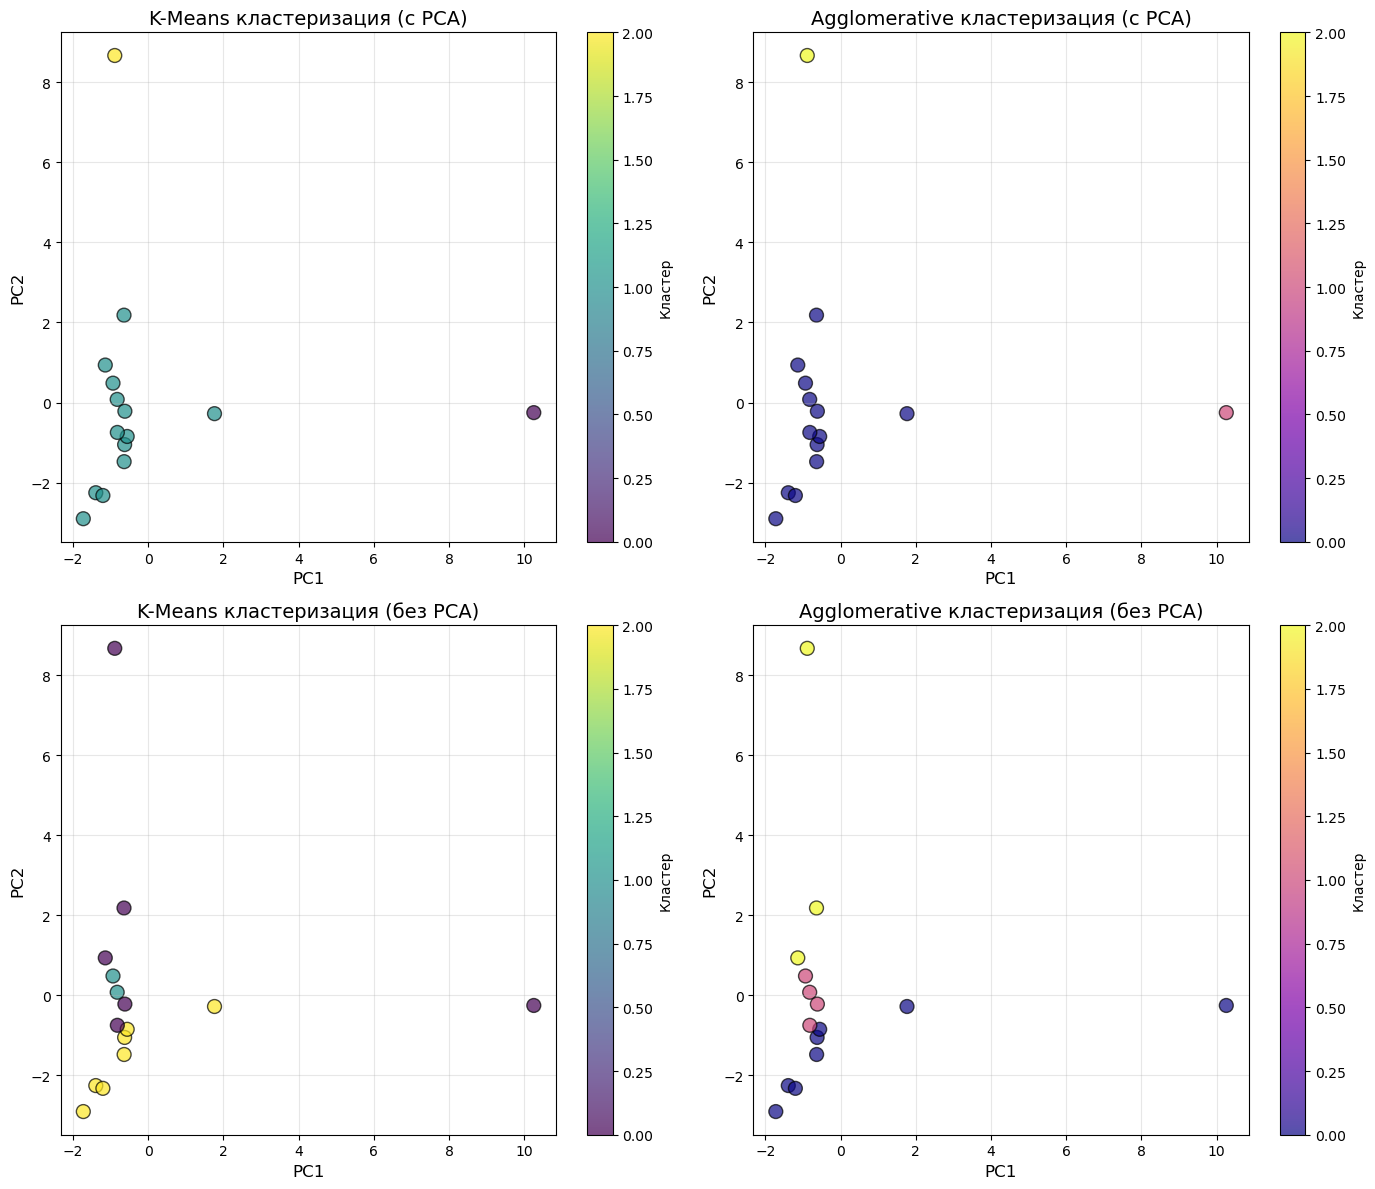

In [43]:
# Визуализация кластеризации в пространстве PCA (2D)
plt.figure(figsize=(14, 12))

# K-Means с PCA
plt.subplot(2, 2, 1)
scatter1 = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                       c=labels_kmeans_pca, cmap='viridis', 
                       s=100, alpha=0.7, edgecolors='black')
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('K-Means кластеризация (с PCA)', fontsize=14)
plt.colorbar(scatter1, label='Кластер')
plt.grid(True, alpha=0.3)

# Agglomerative с PCA
plt.subplot(2, 2, 2)
scatter2 = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                       c=labels_agglo_pca, cmap='plasma', 
                       s=100, alpha=0.7, edgecolors='black')
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('Agglomerative кластеризация (с PCA)', fontsize=14)
plt.colorbar(scatter2, label='Кластер')
plt.grid(True, alpha=0.3)

# K-Means без PCA 
plt.subplot(2, 2, 3)
scatter3 = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                       c=labels_kmeans, cmap='viridis', 
                       s=100, alpha=0.7, edgecolors='black')
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('K-Means кластеризация (без PCA)', fontsize=14)
plt.colorbar(scatter3, label='Кластер')
plt.grid(True, alpha=0.3)

# Agglomerative без PCA
plt.subplot(2, 2, 4)
scatter4 = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                       c=labels_agglo, cmap='plasma', 
                       s=100, alpha=0.7, edgecolors='black')
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('Agglomerative кластеризация (без PCA)', fontsize=14)
plt.colorbar(scatter4, label='Кластер')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<h5>14.2. Дендрограмма иерархической кластеризации.</h5>

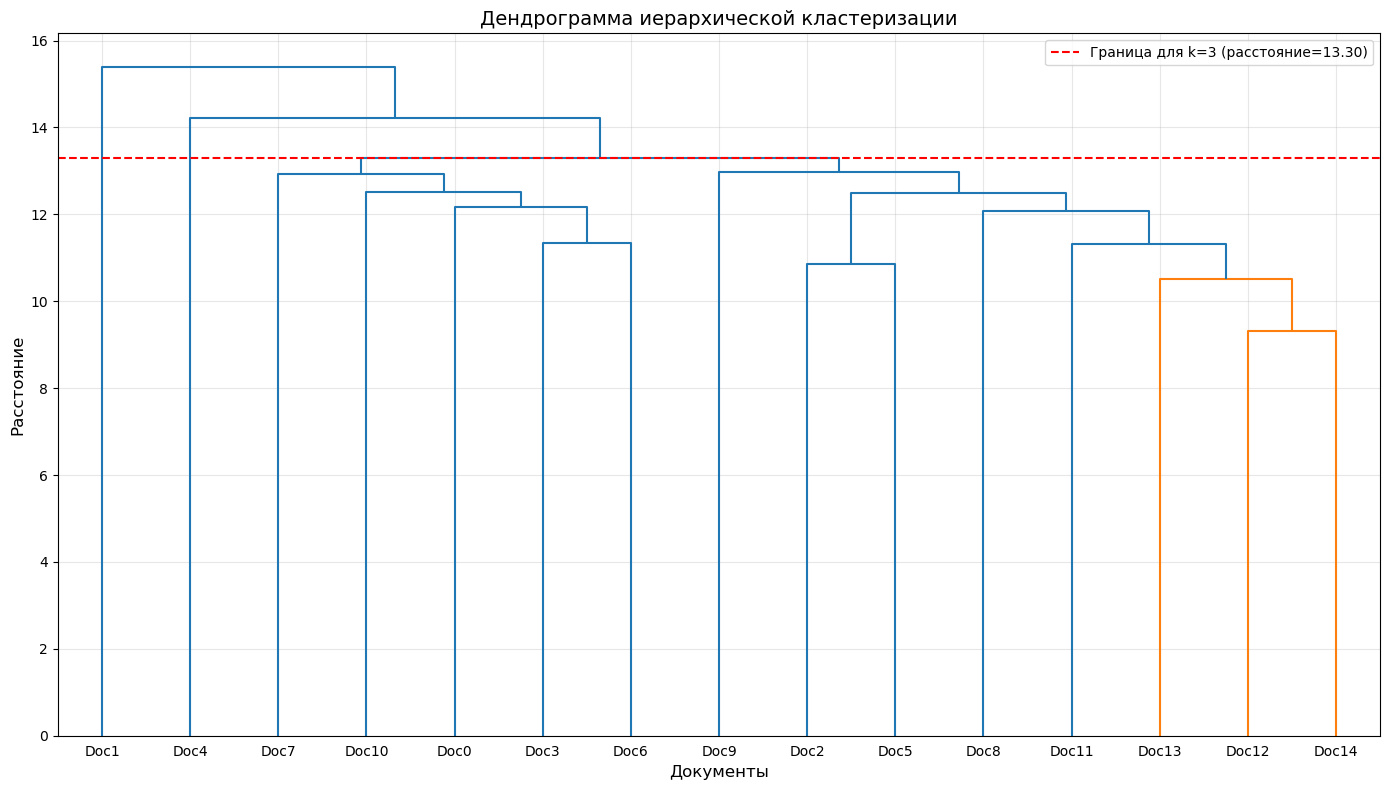

Распределение по кластерам: [ 0 13  1  1]


In [44]:
plt.figure(figsize=(14, 8))

# Создание матрицы связей для дендрограммы
linkage_matrix = linkage(X_scaled, method='ward')

# Построение дендрограммы
dendrogram(
    linkage_matrix, 
    labels=[f'Doc{i}' for i in range(len(documents))],
    leaf_font_size=10,
    color_threshold=0.7 * max(linkage_matrix[:, 2]) # все слияния на расстоянии < 70% от максимального — оранжевые
)

# Автоматическое определение границы для k=3
distance_for_k3 = linkage_matrix[-3, 2]  # Расстояние, дающее ~3 кластера
plt.axhline(y=distance_for_k3, color='r', linestyle='--', 
            label=f'Граница для k=3 (расстояние={distance_for_k3:.2f})')

plt.xlabel('Документы', fontsize=12)
plt.ylabel('Расстояние', fontsize=12)
plt.title('Дендрограмма иерархической кластеризации', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Получение меток кластеров
final_clusters = fcluster(linkage_matrix, 3, criterion='maxclust')
print(f"Распределение по кластерам: {np.bincount(final_clusters)}")

<h5>Вывод: в ходе выполнения работы были применены методы кластеризации для группировки текстовых документов, оценено качество кластеризации с помощью метрик, а также исследовано влияние снижения размерности (PCA) на результаты кластеризации на примере коллекции текстовых документов.</h5>